In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
df_detectability = pd.read_csv("../detectability/detection_results.csv")
df_detectability.head()

,topic,length,AI_model,humanizer,copyleaks_AI,copyleaks_humanized,zerogpt_AI,zerogpt_humanized,sapling_AI,sapling_humanized
0,1,1,gemini2.5pro,AIHumanizer,100.0,100.0,100.00,100.00,99.997658,99.995351
1,1,1,gpt4.0,AIHumanizer,100.0,100.0,100.00,100.00,99.985579,99.961515
2,1,2,gemini2.5pro,AIHumanizer,100.0,100.0,79.21,100.00,99.980250,98.531897
3,1,2,gpt4.0,AIHumanizer,100.0,100.0,100.00,100.00,99.987373,99.995690
4,1,3,gemini2.5pro,AIHumanizer,100.0,100.0,72.07,92.24,79.535308,99.990372


In [4]:
df_factual_forward = pd.read_csv('../factual/qna_results.csv')
df_factual_reversed = pd.read_csv('../factual/qna_results_reversed.csv')
df_factual_forward.head()

,topic,length,AI_model,humanizer,factual_consistency_score,details
0,1,1,gemini2.5pro,AIHumanizer,0.95,[{'question': 'How does the essay describe the...
1,1,1,gemini2.5pro,Grammarly,0.80,[{'question': 'How does the essay describe the...
2,1,1,gemini2.5pro,HumanizeAI,0.85,[{'question': 'How does the essay describe the...
3,1,1,gemini2.5pro,Quillbot,0.90,[{'question': 'How does the essay describe the...
4,1,1,gemini2.5pro,UndetectableAI,0.80,[{'question': 'How does the essay describe the...


In [5]:
df_factual_reversed.head()

,topic,length,AI_model,humanizer,factual_consistency_score,details
0,1,1,gemini2.5pro,AIHumanizer,0.85,[{'question': 'How does the essay describe the...
1,1,1,gemini2.5pro,Grammarly,0.90,"[{'question': ""What has become a big part of y..."
2,1,1,gemini2.5pro,HumanizeAI,0.85,"[{'question': ""What does the essay say about t..."
3,1,1,gemini2.5pro,Quillbot,0.95,"[{'question': ""What is the essay's overall sta..."
4,1,1,gemini2.5pro,UndetectableAI,0.80,[{'question': 'What kind of environment do you...


In [6]:
# merge all 3 data with topic, length, AI_model, humanizer
df_merged = df_factual_forward.merge(df_factual_reversed, on=['topic', 'length', 'AI_model', 'humanizer'], suffixes=('_forward', '_reversed'))
df_merged = df_merged.merge(df_detectability, on=['topic', 'length', 'AI_model', 'humanizer'])
df_merged.head()

,topic,length,AI_model,humanizer,factual_consistency_score_forward,details_forward,factual_consistency_score_reversed,details_reversed,copyleaks_AI,copyleaks_humanized,zerogpt_AI,zerogpt_humanized,sapling_AI,sapling_humanized
0,1,1,gemini2.5pro,AIHumanizer,0.95,[{'question': 'How does the essay describe the...,0.85,[{'question': 'How does the essay describe the...,100.0,100.0,100.0,100.00,99.997658,99.995351
1,1,1,gemini2.5pro,Grammarly,0.80,[{'question': 'How does the essay describe the...,0.90,"[{'question': ""What has become a big part of y...",100.0,100.0,100.0,100.00,99.997658,99.996127
2,1,1,gemini2.5pro,HumanizeAI,0.85,[{'question': 'How does the essay describe the...,0.85,"[{'question': ""What does the essay say about t...",100.0,100.0,100.0,0.00,99.997658,99.843932
3,1,1,gemini2.5pro,Quillbot,0.90,[{'question': 'How does the essay describe the...,0.95,"[{'question': ""What is the essay's overall sta...",100.0,100.0,100.0,64.63,99.997658,30.721407
4,1,1,gemini2.5pro,UndetectableAI,0.80,[{'question': 'How does the essay describe the...,0.80,[{'question': 'What kind of environment do you...,100.0,0.0,100.0,0.00,99.997658,99.351209


In [7]:
# rename column 'factual_consistency_score_forward' to 'factual_forward'
df_merged.rename(columns={'factual_consistency_score_forward': 'factual_forward', 'factual_consistency_score_reversed': 'factual_reversed'}, inplace=True)
df_merged.head()


,topic,length,AI_model,humanizer,factual_forward,details_forward,factual_reversed,details_reversed,copyleaks_AI,copyleaks_humanized,zerogpt_AI,zerogpt_humanized,sapling_AI,sapling_humanized
0,1,1,gemini2.5pro,AIHumanizer,0.95,[{'question': 'How does the essay describe the...,0.85,[{'question': 'How does the essay describe the...,100.0,100.0,100.0,100.00,99.997658,99.995351
1,1,1,gemini2.5pro,Grammarly,0.80,[{'question': 'How does the essay describe the...,0.90,"[{'question': ""What has become a big part of y...",100.0,100.0,100.0,100.00,99.997658,99.996127
2,1,1,gemini2.5pro,HumanizeAI,0.85,[{'question': 'How does the essay describe the...,0.85,"[{'question': ""What does the essay say about t...",100.0,100.0,100.0,0.00,99.997658,99.843932
3,1,1,gemini2.5pro,Quillbot,0.90,[{'question': 'How does the essay describe the...,0.95,"[{'question': ""What is the essay's overall sta...",100.0,100.0,100.0,64.63,99.997658,30.721407
4,1,1,gemini2.5pro,UndetectableAI,0.80,[{'question': 'How does the essay describe the...,0.80,[{'question': 'What kind of environment do you...,100.0,0.0,100.0,0.00,99.997658,99.351209


In [8]:
df_merged.shape

(179, 14)

In [9]:
detector_cols = ['copyleaks_humanized', 'zerogpt_humanized', 'sapling_humanized']
factual_cols = ['factual_forward', 'factual_reversed']
for detector in detector_cols:
    for factual in factual_cols:
        if detector in df_merged.columns and factual in df_merged.columns:
            correlation = df_merged[detector].corr(df_merged[factual])
            print(f"Correlation between {detector} and {factual}: {correlation:.4f}")
        else:
            print(f"Columns {detector} or {factual} not found in the dataset.")

Correlation between copyleaks_humanized and factual_forward: 0.2134
Correlation between copyleaks_humanized and factual_reversed: 0.1830
Correlation between zerogpt_humanized and factual_forward: 0.3336
Correlation between zerogpt_humanized and factual_reversed: 0.2930
Correlation between sapling_humanized and factual_forward: 0.2451
Correlation between sapling_humanized and factual_reversed: 0.0847


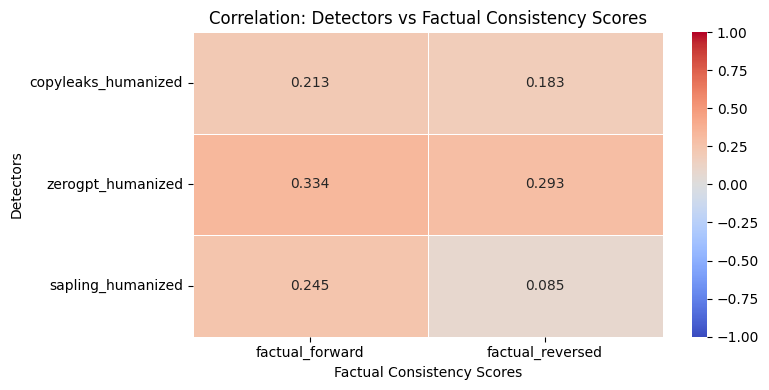

In [14]:
# Plot only detector-to-factual correlations (detectors x factual scores)
corr_subset = df_merged[detector_cols + factual_cols].corr().loc[detector_cols, factual_cols]

plt.figure(figsize=(8, 4))
sns.heatmap(
    corr_subset,
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    fmt='.3f',
    linewidths=0.5
)
plt.title('Correlation: Detectors vs Factual Consistency Scores')
plt.xlabel('Factual Consistency Scores')
plt.ylabel('Detectors')
plt.tight_layout()
plt.show()

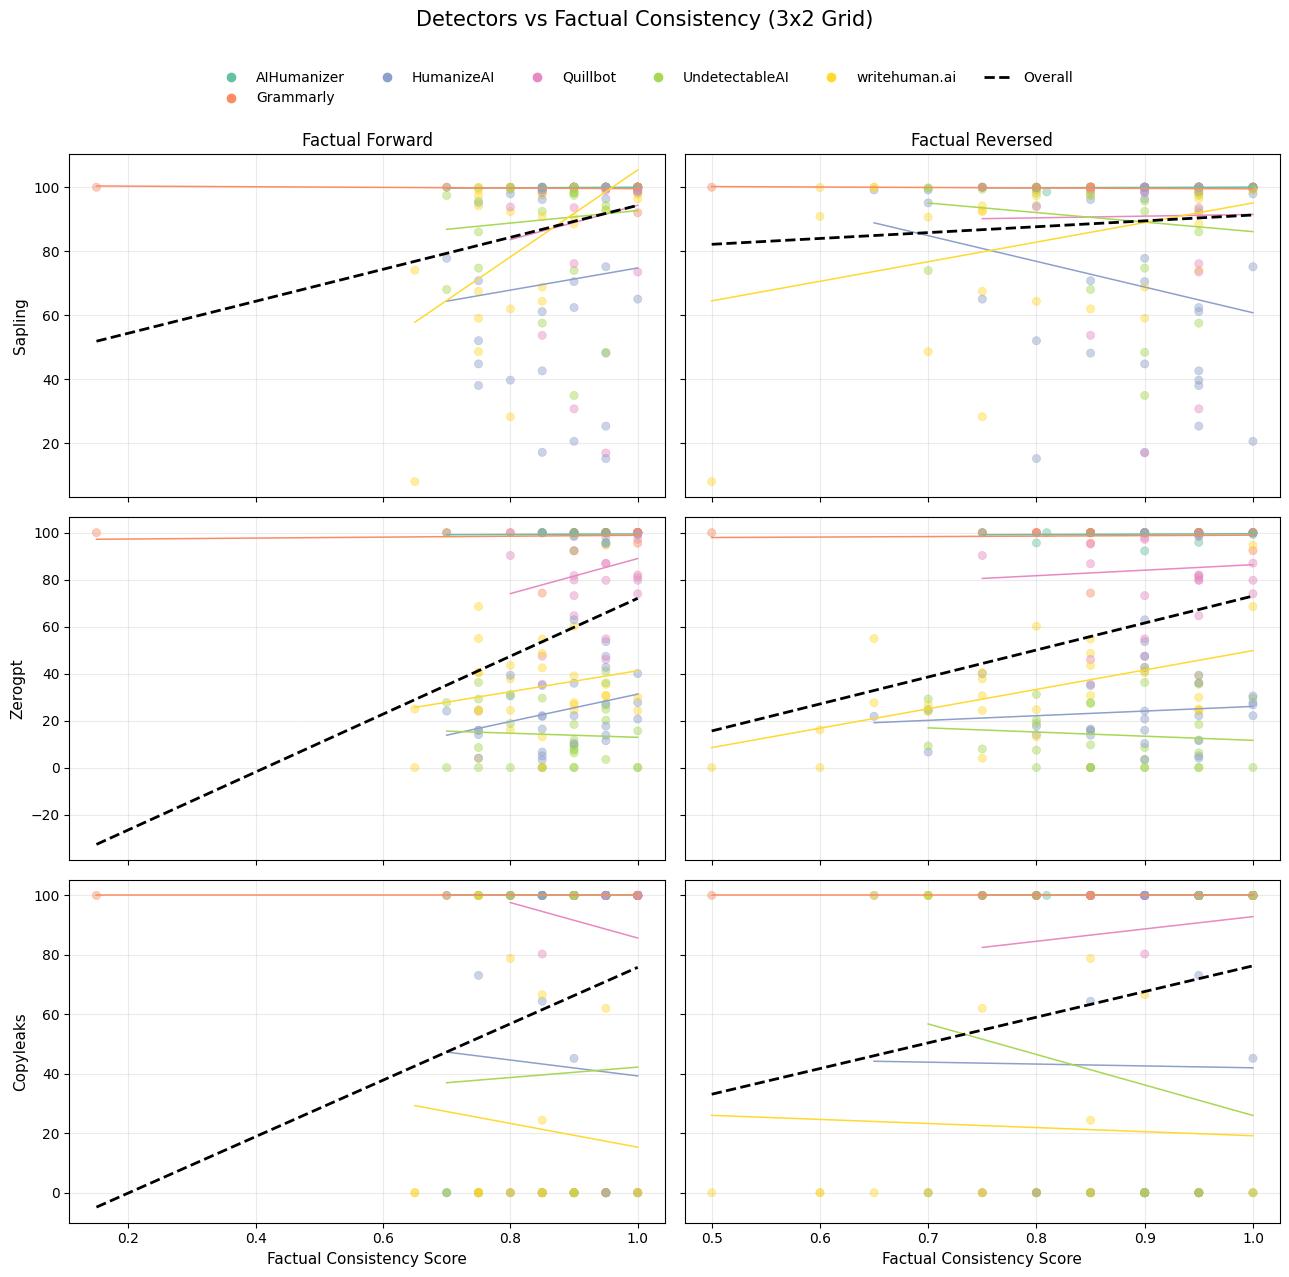

In [ ]:
# Grid plot: 3 detector rows x 2 factual score columns
import numpy as np

detector_cols = ['sapling_humanized', 'zerogpt_humanized', 'copyleaks_humanized']
factual_cols = ['factual_forward', 'factual_reversed']

humanizers = sorted(df_merged['humanizer'].dropna().unique())
palette = dict(zip(humanizers, sns.color_palette('Set2', n_colors=len(humanizers))))

fig, axes = plt.subplots(
    nrows=len(detector_cols),
    ncols=len(factual_cols),
    figsize=(13, 12),
    sharex='col',
    sharey='row'
 )

for i, detector in enumerate(detector_cols):
    for j, factual in enumerate(factual_cols):
        ax = axes[i, j]
        subset = df_merged[[detector, factual, 'humanizer']].dropna()

        # Scatter points per humanizer
        sns.scatterplot(
            data=subset,
            x=factual,
            y=detector,
            hue='humanizer',
            palette=palette,
            alpha=0.45,
            s=35,
            edgecolor=None,
            legend=False,
            ax=ax
        )

        # Regression line per humanizer
        for h in humanizers:
            h_df = subset[subset['humanizer'] == h]
            if len(h_df) >= 2 and h_df[factual].nunique() >= 2:
                x_vals = h_df[factual].values
                y_vals = h_df[detector].values
                m, b = np.polyfit(x_vals, y_vals, 1)
                x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
                ax.plot(x_line, m * x_line + b, color=palette[h], linewidth=1.1)

        # Overall regression line
        if len(subset) >= 2 and subset[factual].nunique() >= 2:
            x_all = subset[factual].values
            y_all = subset[detector].values
            m_all, b_all = np.polyfit(x_all, y_all, 1)
            x_line_all = np.linspace(x_all.min(), x_all.max(), 100)
            ax.plot(
                x_line_all,
                m_all * x_line_all + b_all,
                linestyle='--',
                color='black',
                linewidth=2
            )

        if i == 0:
            title_map = {
                'factual_forward': 'Factual Forward',
                'factual_reversed': 'Factual Reversed'
            }
            ax.set_title(title_map[factual], fontsize=12)

        if j == 0:
            row_label = detector.replace('_humanized', '').capitalize()
            ax.set_ylabel(row_label, fontsize=11)
        else:
            ax.set_ylabel('')

        ax.set_xlabel('')
        ax.grid(True, alpha=0.25)
b
handles = [plt.Line2D([0], [0], color=palette[h], marker='o', linestyle='', markersize=6, label=h) for h in humanizers]
handles.append(plt.Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Overall'))
fig.legend(handles=handles, loc='upper center', ncol=min(6, len(handles)), frameon=False, bbox_to_anchor=(0.5, 1.02))

for ax in axes[-1, :]:
    ax.set_xlabel('Factual Consistency Score', fontsize=11)

plt.suptitle('Detectors vs Factual Consistency (3x2 Grid)', y=1.06, fontsize=15)
plt.tight_layout()
plt.show()

In [17]:
# hypothesis testing whether correlation between detectors and factual scores is significantly different from zero
from scipy.stats import pearsonr

significant_results = []
for detector in detector_cols:
    for factual in factual_cols:
        if detector in df_merged.columns and factual in df_merged.columns:
            subset = df_merged[[detector, factual]].dropna()
            if len(subset) >= 2 and subset[factual].nunique() >= 2:
                corr_coef, p_value = pearsonr(subset[detector], subset[factual])
                significant_results.append({
                    'Detector': detector,
                    'Factual Score': factual,
                    'correlation': corr_coef,
                    'p-value': p_value,
                    'significance': p_value < 0.05
                })
significance_df = pd.DataFrame(significant_results)
display(significance_df)
                

,Detector,Factual Score,correlation,p-value,significance
0,sapling_humanized,factual_forward,0.245062,0.000945,True
1,sapling_humanized,factual_reversed,0.084713,0.259543,False
2,zerogpt_humanized,factual_forward,0.333599,0.000005,True
3,zerogpt_humanized,factual_reversed,0.293007,0.000069,True
4,copyleaks_humanized,factual_forward,0.213405,0.004127,True
5,copyleaks_humanized,factual_reversed,0.183016,0.014199,True
